# Hypergeometric Probability Distribution

## 1. Definition

## 2. Intuition

Hypergeometric is basically the “sampling without replacement” version of the binomial distribution.

Suppose a box contains:
- N total items
- K success items
- N-K failure items

You draw n items without replacement. Let $$X = number of success drawn$$

Then: $$X \textasciitilde Hypergeometric(N,K,n)$$

**Example:** 20 components contain 6 defective components. You inspect 5 without putting any component back. $X$ is the number of defective components in the sample.

## 3. Parameter

There are three parameters: 
- N: total population size 
- K: number of success items 
- n: number of items drawn 


## 4. Support

The upper bound is: $$x_{max} = min(K,n)$$

The lower bound is: $$x_{min} = max(0, n - (N - K))$$

So: $$max(0,n-(N_K))\leq X \leq min(K,n)$$

## 5. Probability Mass Function

$$P(X=x) = \frac{\begin{pmatrix}{K}\cr{x}\cr\end{pmatrix} \begin{pmatrix}{N-K}\cr{n-x}\cr\end{pmatrix}}{\begin{pmatrix}N\cr n\cr\end{pmatrix}}$$

## 6. Cumulative Distribution Function


## 7. Moments

Mean: $n \frac {K}{N}$

Variance: $\frac{N-n}{N-1}$

## 8. NumPy Implementation

In [1]:
import numpy as np
import matplotlib as plt

In [2]:
import numpy as np


class Hypergeometric:
    """
    Hypergeometric distribution.

    Parameters
    ----------
    population_size : int
        Total number of items in the population.

    successes : int
        Number of success items in the population.

    draws : int
        Number of items drawn without replacement.

    Random variable
    ---------------
    X = number of successes in the drawn sample.
    """

    def __init__(
        self,
        population_size: int,
        successes: int,
        draws: int,
    ):
        parameters = {
            "population_size": population_size,
            "successes": successes,
            "draws": draws,
        }

        for name, value in parameters.items():
            if not isinstance(value, (int, np.integer)):
                raise TypeError(f"{name} must be an integer.")

        if population_size < 1:
            raise ValueError("population_size must be at least 1.")

        if not 0 <= successes <= population_size:
            raise ValueError(
                "successes must lie between 0 and population_size."
            )

        if not 0 <= draws <= population_size:
            raise ValueError(
                "draws must lie between 0 and population_size."
            )

        self.population_size = int(population_size)
        self.successes = int(successes)
        self.draws = int(draws)

        self.failures = self.population_size - self.successes

        self.min_support = max(
            0,
            self.draws - self.failures,
        )

        self.max_support = min(
            self.draws,
            self.successes,
        )

        self.support = np.arange(
            self.min_support,
            self.max_support + 1,
        )

    def _factorial(self, n: int) -> int:
        """
        Compute n! recursively.
        """

        if n == 0 or n == 1:
            return 1

        return n * self._factorial(n - 1)

    def _combination(self, n: int, k: int) -> int:
        """
        Compute the binomial coefficient:

            C(n, k) = n! / (k! (n-k)!)
        """

        if k < 0 or k > n:
            return 0

        return (
            self._factorial(n)
            //
            (
                self._factorial(k)
                * self._factorial(n - k)
            )
        )

    def pmf(self, x):
        """
        Probability mass function:

                        C(K, x) C(N-K, n-x)
            P(X=x) = ----------------------
                              C(N, n)

        where:

            N = population_size
            K = successes
            n = draws
        """

        x = np.asarray(x)

        P = np.zeros_like(x, dtype=float)

        valid = (
            (x >= self.min_support)
            & (x <= self.max_support)
            & (x == np.floor(x))
        )

        x_valid = x[valid].astype(int)

        denominator = self._combination(
            self.population_size,
            self.draws,
        )

        combination_successes = np.array(
            [
                self._combination(self.successes, value)
                for value in x_valid
            ],
            dtype=float,
        )

        combination_failures = np.array(
            [
                self._combination(
                    self.failures,
                    self.draws - value,
                )
                for value in x_valid
            ],
            dtype=float,
        )

        P[valid] = (
            combination_successes
            * combination_failures
            / denominator
        )

        return P

    def cdf(self, x):
        """
        Cumulative distribution function:

            F(x) = P(X <= x)
        """

        x = np.asarray(x)

        F = np.zeros_like(x, dtype=float)

        F[x >= self.max_support] = 1.0

        valid = (
            (x >= self.min_support)
            & (x < self.max_support)
        )

        cumulative_probabilities = np.cumsum(
            self.pmf(self.support)
        )

        indices = (
            np.floor(x[valid]).astype(int)
            - self.min_support
        )

        F[valid] = cumulative_probabilities[indices]

        return F

    def mean(self):
        """
        Expected value:

            E[X] = draws * successes / population_size
        """

        return (
            self.draws
            * self.successes
            / self.population_size
        )

    def variance(self):
        """
        Variance:

                   K       K       N-n
            n * (---) * (1---) * -----
                   N       N       N-1
        """

        if self.population_size == 1:
            return 0.0

        success_probability = (
            self.successes / self.population_size
        )

        finite_population_correction = (
            (self.population_size - self.draws)
            / (self.population_size - 1)
        )

        return (
            self.draws
            * success_probability
            * (1 - success_probability)
            * finite_population_correction
        )

    def sample(self, size=1, random_state=None):
        """
        Generate samples by drawing without replacement.

        Returns the number of success items in each sample.
        """

        if not isinstance(size, (int, np.integer)):
            raise TypeError("size must be an integer.")

        if size < 1:
            raise ValueError("size must be at least 1.")

        rng = np.random.default_rng(random_state)

        population = np.concatenate(
            (
                np.ones(self.successes, dtype=int),
                np.zeros(self.failures, dtype=int),
            )
        )

        samples = np.empty(size, dtype=int)

        for index in range(size):
            selected_items = rng.choice(
                population,
                size=self.draws,
                replace=False,
            )

            samples[index] = np.sum(selected_items)

        return samples

    def plot(self, figsize=(10, 4)):
        """
        Plot the PMF and CDF.
        """

        import matplotlib.pyplot as plt

        pmf_values = self.pmf(self.support)
        cdf_values = self.cdf(self.support)

        fig, axes = plt.subplots(
            1,
            2,
            figsize=figsize,
        )

        axes[0].bar(
            self.support,
            pmf_values,
        )

        axes[0].set_title("Hypergeometric PMF")
        axes[0].set_xlabel("Number of Successes Drawn")
        axes[0].set_ylabel("Probability")
        axes[0].set_xticks(self.support)
        axes[0].grid(True, axis="y")

        axes[1].step(
            self.support,
            cdf_values,
            where="post",
        )

        axes[1].scatter(
            self.support,
            cdf_values,
        )

        axes[1].set_title("Hypergeometric CDF")
        axes[1].set_xlabel("Number of Successes Drawn")
        axes[1].set_ylabel("Cumulative Probability")
        axes[1].set_xticks(self.support)
        axes[1].set_ylim(0, 1.05)
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

Support: [0 1 2 3 4 5]
PMF: [1.29127967e-01 3.87383901e-01 3.52167183e-01 1.17389061e-01
 1.35448916e-02 3.86996904e-04]
CDF: [0.12912797 0.51651187 0.86867905 0.98606811 0.999613   1.        ]
Mean: 1.5
Variance: 0.8289473684210525
Samples: [1 1 1 1 2 0 2 1 1 1]


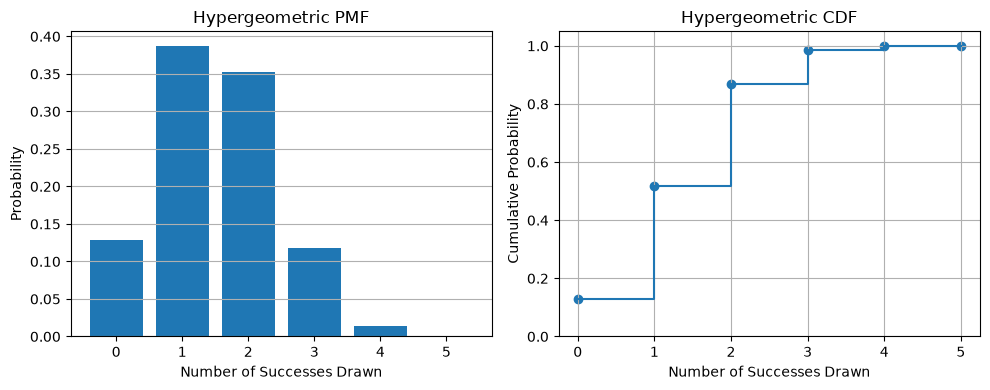

In [3]:
distribution = Hypergeometric(
    population_size=20,
    successes=6,
    draws=5,
)

print("Support:", distribution.support)
print("PMF:", distribution.pmf(distribution.support))
print("CDF:", distribution.cdf(distribution.support))
print("Mean:", distribution.mean())
print("Variance:", distribution.variance())
print(
    "Samples:",
    distribution.sample(
        size=10,
        random_state=42,
    ),
)

distribution.plot()